# Tikhonov regularization, the conjugate gradient method and the L-curve
Consider the problem from lab 3. Another approach that can avoid the effects of semi-convergence is to solve instead of the least-squares problem
$$ \min_{\alpha} \frac{1}{2} \| A \alpha - g \|^2 $$
the regularized problem
$$ \min_{\alpha} \frac{1}{2} \| A \alpha - g \|^2 + \frac{\lambda}{2} \| \alpha \|^2 $$
with a regularization parameter $\lambda > 0$. It turns out that for a suitably chosen parameter $\lambda$ (depending on the noise level and the problem) the exact solution of the regularized problem (here with [Tikhonov regularization](https://en.wikipedia.org/wiki/Tikhonov_regularization)) is often a more accurate reconstruction than a solution of the unregularized problem (though there are typically better regularization alternatives). The optimality condition now reads $0 = A^* (A \alpha - g) + \lambda \alpha$. For the reconstruction problem described in lab 3, find a regularized solution for some choice of $\lambda$ using the conjugate gradient method and plot the relative error. Then, try to find a good choice of the parameter $\lambda$ with the L-curve method. For the L-curve you should not do a full reconstruction for each $\lambda$, but only a few iterations to save time. Compare with the Landweber solution.

Some hints:

* As in lab 3, if you do not have a GPU, or if you have not installed astra-toolbox, then this lab must be done in two dimensions.

* You can form the [identity operator](https://odlgroup.github.io/odl/generated/odl.operator.default_ops.IdentityOperator.html) of a space and add a scaled version of it to another operator, in order to implement Tikhonov regularization.

* There are many [algorithmic solvers](https://odlgroup.github.io/odl/odl.solvers.html) available in ODL, including the [conjugate gradient](https://odlgroup.github.io/odl/generated/odl.solvers.iterative.iterative.conjugate_gradient.html) method, for which you need to make your operator self-adjoint.

In [1]:
import odl
import numpy as np
import matplotlib.pyplot as plt

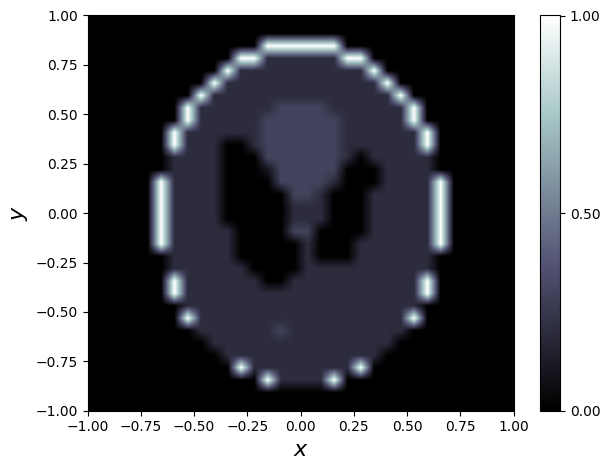

<Figure size 640x480 with 0 Axes>

In [2]:
space = odl.discr.discr_space.uniform_discr([-1, -1, -1], [1, 1, 1], (32, 32, 32))

phantom = odl.phantom.transmission.shepp_logan(space=space, modified=True)
phantom.show()
plt.close()

In [3]:

geometry = odl.tomo.geometry.conebeam.cone_beam_geometry(space=space, 
                                                         src_radius=5,
                                                         det_radius=5, 
                                                         num_angles=12)

id = odl.operator.default_ops.IdentityOperator(space=space)
Ray = odl.tomo.operators.ray_trafo.RayTransform(vol_space=space, geometry=geometry, impl="astra_cuda")

sinogram = Ray(phantom)
Ray_range = Ray.range
stddev = 0.01
noisy_sinogram = sinogram + odl.phantom.white_noise(space=Ray_range, mean=0.0, stddev=stddev, seed=42)
y = noisy_sinogram



/home/ahopkins/KTH_TTMAM/SF2529_HT25/.venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


**Note**
* Tikhonov:
$$
    \min_{x} \frac{1}{2} \| A x - y \|^2 + \frac{\lambda}{2} \| x \|^2 
$$

* "Normal equations" (setting gradient to zero):
$$
    (A^*A + \lambda I)(x) = A^*(y)
$$
And we note:
* $A^*: Y \rightarrow X$ is the adjoint
* $A^*A: X \to X$ is self-adjoint and positive semidefinite
* $A^*A + \lambda I$ is self-adjoint, bounded, and strictly positive definite (if $\lambda \gt 0$)

Therefore we instead solve:
$$
    M(x) = b, \quad \text{where} \quad M = (A^*A + \lambda I), \enspace b = A^*y
$$
Using Conjugate Gradient Decent

### Conjugate Gradient Decent Method

In [4]:
def Tikhonov(A, x, y, lam):
    return 0.5*(A(x) - y).norm()**2 + lam/2 * x.norm()**2

def CGD_Tikhonov(op, y, lam, x0, niter, x_true=None, tol=None):
    A = op
    Adj = A.adjoint
    id = odl.operator.default_ops.IdentityOperator(space=A.domain)
    M = Adj * A + lam * id
    b = Adj(y)
    
    r0 = b - M(x0)  # Initial residual
    p0 = r0         # Initial search direction 
    
    # Store Convergence & Solutions
    solutions = [x0]
    obj_errors = np.zeros(niter+1)
    obj_errors[0] = Tikhonov(A, x0, y, lam)
    if x_true is not None:
        rel_errors = np.zeros(niter+1)
        rel_errors[0] = (x0 - x_true).norm() / x_true.norm()
    
    xk, rk, pk = x0, r0, p0
    for k in range(niter):
        qk = M(pk)
        alphak = rk.inner(rk) / pk.inner(qk)
        xk_1 = xk + alphak * pk
        rk_1 = rk - alphak * qk
        
        obj_errors[k+1] = Tikhonov(A, xk, y, lam)
        if x_true is not None:
            rel_errors[k+1] = (xk - x_true).norm() / x_true.norm()
        
        solutions.append(xk)
        
        res_norm = rk_1.norm()
        if tol is not None and res_norm < tol:
            print(f"Exit Tolerance met after {k+1} iterations")
            obj_errors = obj_errors[:k+2]
            if x_true is not None:
                rel_errors = rel_errors[:k+2]
            xk, rk = xk_1, rk_1
            break
        
        betak = rk_1.inner(rk_1) / rk.inner(rk)
        pk_1 = rk_1 + betak * pk 
        xk, rk, pk = xk_1, rk_1, pk_1
        
    # Find best solution if possible
    best_sol = None
    if x_true is not None:
        best_sol = solutions[int(np.argmin(rel_errors))]
    return best_sol, solutions, (rel_errors if x_true is not None else None), obj_errors

    
    

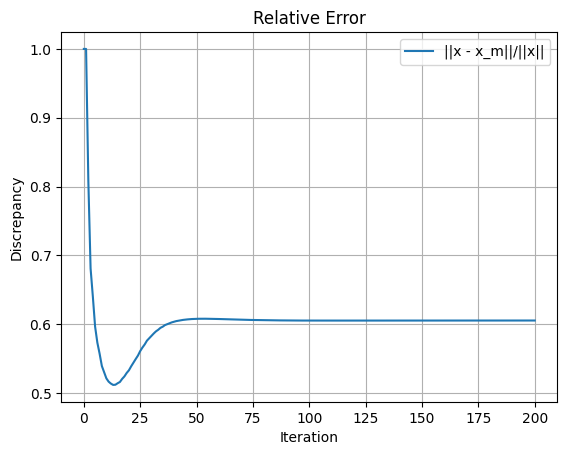

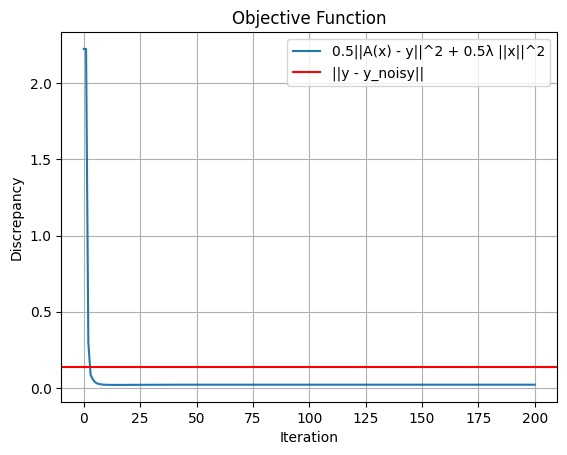

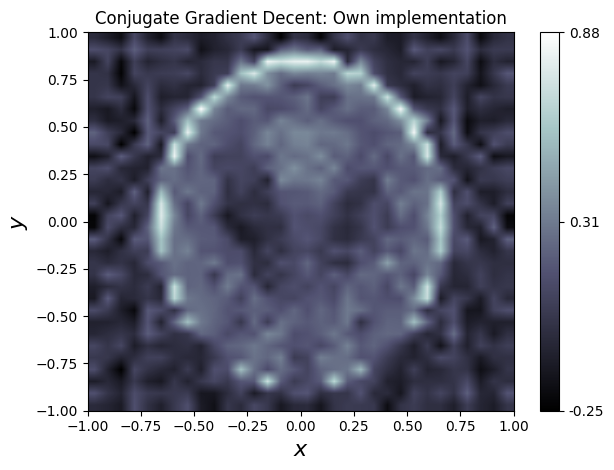

<Figure size 640x480 with 0 Axes>

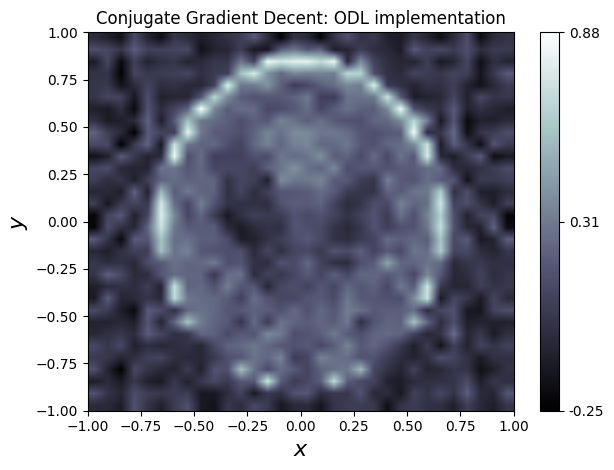

<Figure size 640x480 with 0 Axes>

In [5]:
x_init = space.zero()
lam = 0.1

best_sol, solutions, rel_errors, obj_errors = CGD_Tikhonov(op=Ray, 
                                                           y = noisy_sinogram, 
                                                           lam = lam, 
                                                           x0 = x_init, 
                                                           niter = 200, 
                                                           x_true = phantom, 
                                                           )

plt.plot(np.arange(len(rel_errors)), rel_errors, label=r"||x - x_m||/||x||")
plt.xlabel("Iteration"); plt.ylabel("Discrepancy")
plt.title("Relative Error")
plt.legend(); plt.grid(True)
plt.show()

plt.plot(np.arange(len(obj_errors)), obj_errors, label=r"0.5||A(x) - y||^2 + 0.5λ ||x||^2")
plt.axhline(y=(noisy_sinogram-sinogram).norm(), color="r", label=r"||y - y_noisy||")
plt.xlabel("Iteration"); plt.ylabel("Discrepancy")
plt.title("Objective Function")
plt.legend(); plt.grid(True)
plt.show()

best_sol.show(title="Conjugate Gradient Decent: Own implementation")

x = x_init
odl.solvers.iterative.iterative.conjugate_gradient(op = Ray.adjoint * Ray + lam * id, 
                                                   x = x,
                                                   rhs = Ray.adjoint(noisy_sinogram), 
                                                   niter = int(np.argmin(rel_errors))
                                                   )
x.show(title="Conjugate Gradient Decent: ODL implementation")

plt.close()

### L-Curve Method


In [ ]:
lambdas = 10 ** np.linspace(-4, 0, 20)
nr_iter = 10

res_norms = np.zeros(len(lambdas))
x_norms = np.zeros(len(lambdas))


for i, lam in enumerate(lambdas):
    x = space.zero()
    odl.solvers.iterative.iterative.conjugate_gradient(op = Ray.adjoint * Ray + lam * id, 
                                                   x = x,
                                                   rhs = Ray.adjoint(noisy_sinogram), 
                                                   niter = nr_iter
                                                   )
    res_norms[i] = (Ray(x) - noisy_sinogram).norm()
    x_norms[i] = x.norm()


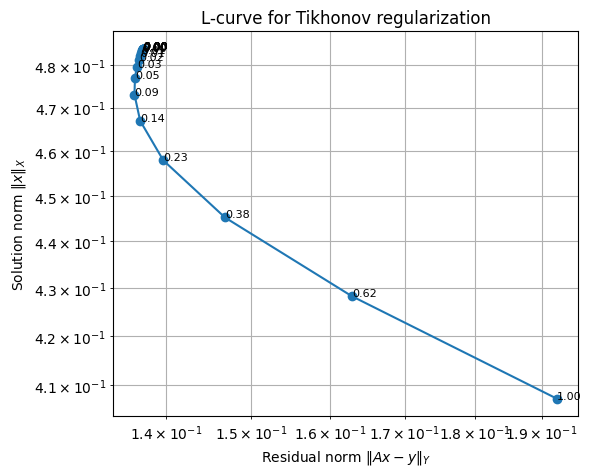

In [7]:

# ---- Plot L-curve ----
plt.figure(figsize=(6,5))
plt.loglog(res_norms, x_norms, 'o-')
for i, lam in enumerate(lambdas):
    plt.text(res_norms[i], x_norms[i], f"{lam:.2f}", fontsize=8)

plt.xlabel(r"Residual norm $\|Ax - y\|_Y$")
plt.ylabel(r"Solution norm $\|x\|_X$")
plt.title("L-curve for Tikhonov regularization")
plt.grid(True, which="both")
plt.show()


* From plot: choose $\lambda = 0.6$

In [8]:
def Landweber(op, x_init, y, niter, x_true=None, tol=None):
    A = op
    Adj = A.adjoint
    w = 1 / A.norm(estimate=True)**2
    
    # Objective function value (error) tracking
    obj_errors = np.zeros(niter+1)
    obj_errors[0] = 0.5 * (A(x_init) - y).norm()**2
    
    # Deviation from true solution tracking (if availible)
    if not x_true is None:
        rel_errors = np.zeros(niter+1)
        rel_errors[0] = (x_init - x_true).norm() / x_true.norm()
    
    # Also store all solutions
    solutions = [x_init]
    
    x_m = x_init
    for m in range(1, niter+1):
        x_mp1 =  x_m - w * Adj(A(x_m) - y)
        x_m = x_mp1
        
        # Store norms
        rel_errors[m] = (x_m - x_true).norm() / x_true.norm()
        obj_errors[m] = 0.5 * (A(x_m) - y).norm()**2
        solutions.append(x_m)
        if not tol is None and obj_errors[m] < tol:
            print(f"Exit Tolerance met after {m} iterations")
            obj_errors = obj_errors[:m+2]
            if x_true is not None:
                rel_errors = rel_errors[:m+2]
            break
    
    # find best solution if able
    best_sol = None
    if x_true is not None:
        best_sol = solutions[int(np.argmin(rel_errors))]
    return best_sol, solutions, (rel_errors if x_true is not None else None), obj_errors


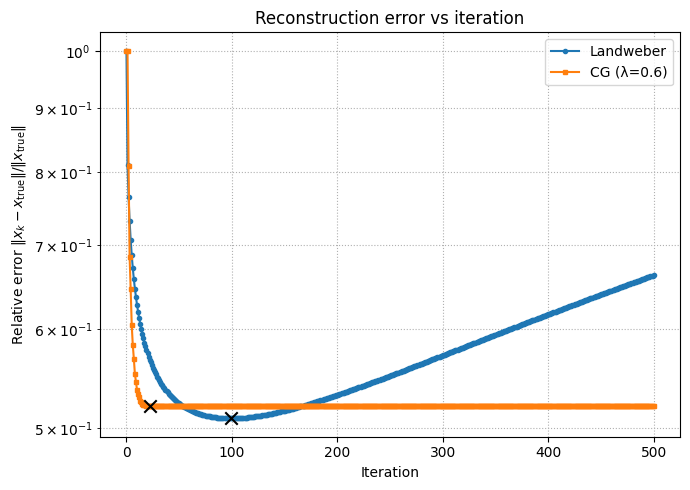

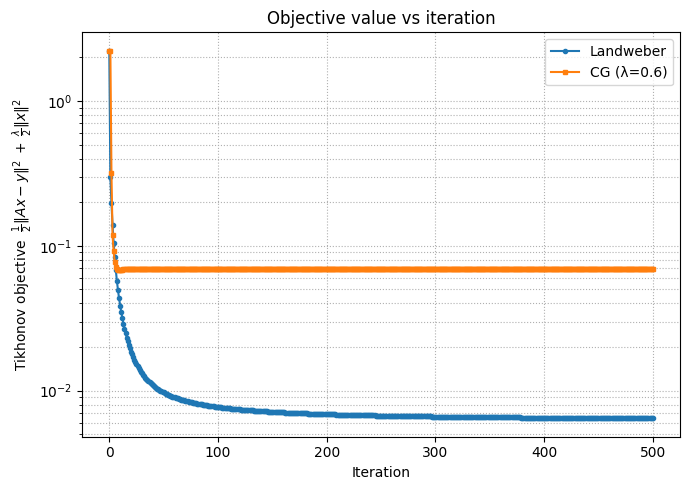

In [9]:
x_init = space.zero()
nr_iter = 500

Landw_best_sol, Landw_solutions, Landw_rel_errors, Landw_obj_errors = Landweber(op=Ray, 
                                                                                x_init=x_init, 
                                                                                y=noisy_sinogram, 
                                                                                niter=nr_iter, 
                                                                                x_true=phantom)

lam = 0.6
CGD_best_sol, CGD_solutions, CGD_rel_errors, CGD_obj_errors = CGD_Tikhonov(op=Ray, 
                                                                           y = noisy_sinogram, 
                                                                           lam = lam, 
                                                                           x0 = x_init, 
                                                                           niter = nr_iter, 
                                                                           x_true = phantom, 
                                                                            )

# --- Build iteration indices (handles early stopping lengths) ---
it_L = np.arange(len(Landw_rel_errors))          # includes initial at 0
it_C = np.arange(len(CGD_rel_errors))

# --- Relative error (use semilogy to see rates clearly) ---
plt.figure(figsize=(7,5))
plt.semilogy(it_L, Landw_rel_errors, label="Landweber", marker='o', ms=3)
plt.semilogy(it_C, CGD_rel_errors, label=f"CG (λ={lam})", marker='s', ms=3)
plt.xlabel("Iteration")
plt.ylabel(r"Relative error $\|x_k - x_\mathrm{true}\| / \|x_\mathrm{true}\|$")
plt.title("Reconstruction error vs iteration")
plt.grid(True, which="both", ls=':')
plt.legend()
plt.tight_layout()

# --- Optionally mark the best iterate for each method ---
kL = int(np.argmin(Landw_rel_errors))
kC = int(np.argmin(CGD_rel_errors))
plt.scatter([kL], [Landw_rel_errors[kL]],
            marker='x', s=80, c='black', zorder=3, label="Landweber best")

plt.scatter([kC], [CGD_rel_errors[kC]],
            marker='x', s=80, c='black', zorder=3, label="CG best")


# --- Objective value histories (Tikhonov) ---
it_L_obj = np.arange(len(Landw_obj_errors))
it_C_obj = np.arange(len(CGD_obj_errors))

plt.figure(figsize=(7,5))
plt.semilogy(it_L_obj, Landw_obj_errors, label="Landweber", marker='o', ms=3)
plt.semilogy(it_C_obj, CGD_obj_errors, label=f"CG (λ={lam})", marker='s', ms=3)
plt.xlabel("Iteration")
plt.ylabel(r"Tikhonov objective  $\frac{1}{2}\|Ax - y\|^2 \;+\; \frac{\lambda}{2}\|x\|^2$")
plt.title("Objective value vs iteration")
plt.grid(True, which="both", ls=':')
plt.legend()
plt.tight_layout()


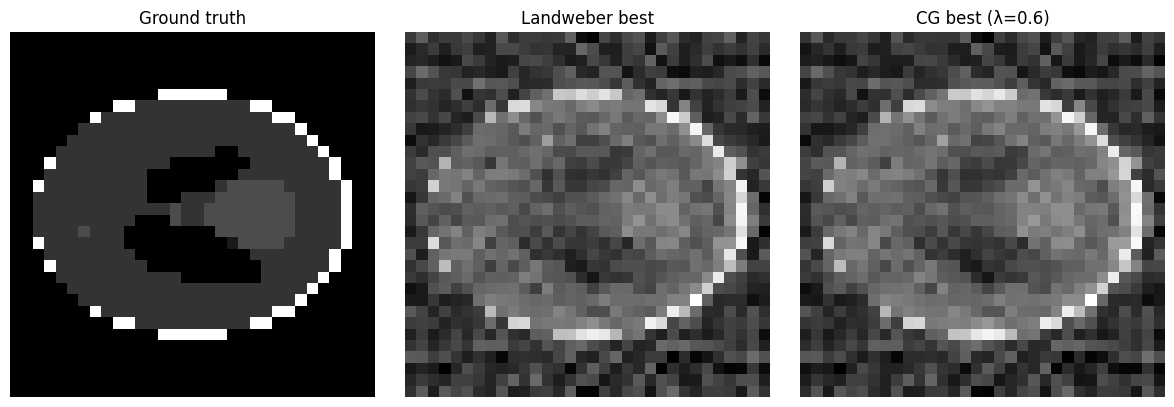

In [10]:
def get_slice2d(elt, axis=2, index=None):
    arr = elt.asarray()
    if index is None:
        index = arr.shape[axis] // 2  # middle slice
    sl = [slice(None)] * arr.ndim
    sl[axis] = index
    return arr[tuple(sl)]

idx_axis, idx = 2, None  # z-slice, middle
phantom_slice = get_slice2d(phantom, axis=idx_axis, index=idx)
landw_slice   = get_slice2d(Landw_best_sol, axis=idx_axis, index=idx)
cgd_slice     = get_slice2d(CGD_best_sol, axis=idx_axis, index=idx)

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, img, title in zip(
    axes,
    [phantom_slice, landw_slice, cgd_slice],
    ["Ground truth", "Landweber best", f"CG best (λ={lam})"]
):
    ax.imshow(img, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

